In [18]:
import os
import torch
from d2l import torch as d2l

# 1. Bilingual Raw Text
# 2. Text Preprocessing
# 3. Source/Target 분리
# 4. Word-Level Tokenization
# 5. <eos> 추가
# 6. Vocabulary
# 7. Padding / Truncation
# 8. Fixed-Length Tensor
# 9. DataLoader

In [19]:
# English-French Dataset Download

class MTFraEng(d2l.DataModule):
    
    def _download(
        self,
    ) -> str:
        
        archive_path = d2l.download(
            d2l.DATA_URL + "fra-eng.zip",
            self.root,
            "94646ad1522d915e7b0f9296181140edcf86a4f5",
        )

        d2l.extract(
            archive_path
        )

        text_path = os.path.join(
            self.root,
            "fra-eng",
            "fra.txt",
        )

        with open(
            text_path,
            encoding="utf-8",
        ) as file:
            return file.read()


In [20]:
# Raw Text 확인

data = MTFraEng()

raw_text = data._download()

print(
    "Dataset root:",
    os.path.abspath(data.root),
)

print(
    "\nRaw text:"
)

print(
    raw_text[:75]
)

Dataset root: /home/anna/projects/maverick/src/ch10_modern_recurrent_neural_networks/data

Raw text:
Go.	Va !
Hi.	Salut !
Run!	Cours !
Run!	Courez !
Who?	Qui ?
Wow!	Ça alors !



In [21]:
# Text Preprocessing

def mtfraeng_preprocess(
    self: MTFraEng,
    text: str
) -> str:

    # 1) Unicode Space -> 일반 Space    
    text = (
        text
        .replace("\u202f", " ")
        .replace("\xa0", " ")
    )

    # 2) Uppercase -> Lowercase
    lower_text = text.lower()

    output: list[str] = []

    # Character를 하나씩 확인
    for index, character in enumerate(
        lower_text
    ):
        
        is_punctuation = (
            character in ",.!?"
        )
        
        has_previous_character = (
            index > 0
        )

        previous_is_not_space = (
            has_previous_character
            and lower_text[index - 1] != " "
        )

        # 3) Punctuation 앞에 Space 삽입
        # : "go." → "go ."
        if (
            is_punctuation
            and previous_is_not_space
        ):
            output.append(
                " "
            )
            
        output.append(
            character
        )
        
    return "".join(output)


setattr(
    MTFraEng,
    "_preprocess",
    mtfraeng_preprocess,
)

In [22]:
# Preprocessing

text = data._preprocess(
    raw_text
)

print(
    text[:80]
)

go .	va !
hi .	salut !
run !	cours !
run !	courez !
who ?	qui ?
wow !	ça alors !


In [23]:
# 3) Word-Level Tokenization

def mtfraeng_tokenize(
    self: MTFraEng,
    text: str,
    max_examples: int | None = None,
) -> tuple[
    list[list[str]],
    list[list[str]],
]:
    
    source: list[list[str]] = []
    target: list[list[str]] = []
    
    # 전체 text를 newline 기준으로 분리: "go .\tva !"
    for line in text.splitlines():
        
        if (
            max_examples is not None
            and len(source) >= max_examples
        ):
            break
        
        
        # Tab을 기준으로 English와 French를 분리:
        parts = line.split("\t")
        
        
        # 정상적인 Translation pair가 아니라면 pass
        if len(parts) != 2:
            continue
        
        
        # part[0]: "go ."
        # part[1]: "va !"
        source_text = parts[0]
        target_text = parts[1]
        
        source_tokens = source_text.split() # source: ["go", "."]
        target_tokens = target_text.split() # target: ["va", "!"]

        # <bos>: Begin of Sequence  
        # <eos>: End of Sequence
        source_tokens.append("<eos>") # ["go", ".", "<eos>"]
        target_tokens.append("<eos>") # ["va", "!", "<eos>"]
        
        source.append(
            source_tokens
        )
        target.append(
            target_tokens
        )
        
    return source, target


setattr(
    MTFraEng,
    "_tokenize",
    mtfraeng_tokenize,
)

In [24]:
# Tokenization 결과

source, target = data._tokenize(
    text,
    max_examples=10,
)

print("Source sequences:")

for tokens in source:
    print(
        tokens
    )

print("\nTarget sequences:")

for tokens in target:
    print(
        tokens
    )


Source sequences:
['go', '.', '<eos>']
['hi', '.', '<eos>']
['run', '!', '<eos>']
['run', '!', '<eos>']
['who', '?', '<eos>']
['wow', '!', '<eos>']
['fire', '!', '<eos>']
['help', '!', '<eos>']
['jump', '.', '<eos>']
['stop', '!', '<eos>']

Target sequences:
['va', '!', '<eos>']
['salut', '!', '<eos>']
['cours', '!', '<eos>']
['courez', '!', '<eos>']
['qui', '?', '<eos>']
['ça', 'alors', '!', '<eos>']
['au', 'feu', '!', '<eos>']
['à', "l'aide", '!', '<eos>']
['saute', '.', '<eos>']
['ça', 'suffit', '!', '<eos>']


In [25]:
# 4) Sequence Length Histogram

def show_list_len_pair_hist(
    legend: list[str],
    xlabel: str,
    ylabel: str,
    source_sequences: list[list[str]],
    target_sequences: list[list[str]],
) -> None:
    
    # 각 source sequence의 Token 수를 계산:
    #  ["go", ".", "<eos>"] → 3
    source_lengths = [
        len(sequence)
        for sequence in source_sequences
    ]

    # 각 target sequence의 Token 수를 계산:
    # ["ça", "alors", "!", "<eos>"] -> 4
    target_lengths = [
        len(sequence)
        for sequence in target_sequences
    ]

    d2l.set_figsize()

    _, _, patches = d2l.plt.hist(
        [
            source_lengths,
            target_lengths,
        ]
    )

    d2l.plt.xlabel(
        xlabel
    )

    d2l.plt.ylabel(
        ylabel
    )

    # Target Histogram에 빗금 Pattern을 추가해
    # Source Histogram과 쉽게 구분한다.
    for patch in patches[1]:
        patch.set_hatch("/")

    d2l.plt.legend(
        legend
    )

Number of sentence pairs: 167130


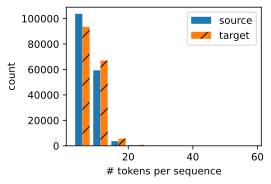

In [26]:
# 전체 Dataset의 Sequence Length 확인

source, target = data._tokenize(
    text
)

print(
    "Number of sentence pairs:",
    len(source),
)

show_list_len_pair_hist(
    legend=[
        "source",
        "target",
    ],
    xlabel="# tokens per sequence",
    ylabel="count",
    source_sequences=source,
    target_sequences=target,
)